<a href="https://colab.research.google.com/github/IgQue/Algoritmo-Stokes/blob/main/Atividade1_10819332.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Igor Quereli , N.USP : 10819332**
# **Aprendizado de máquina e inteligência artificial em física**
# **Atividade 1**

## Importando bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mpl_toolkits.mplot3d
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

## Carregando base de dados
Os dados são carregados utilizando a função de leitura de arquivos CSV da biblioteca Pandas

In [2]:
dados = pd.read_csv('Stars.csv')
dados

,Star,Temperature,L,R,A_M,Color,Spectral_Class
0,1,3068,0.002400,0.1700,16.12,Red,M
1,2,3042,0.000500,0.1542,16.60,Red,M
2,3,2600,0.000300,102.0000,18.70,Red,M
3,4,2800,0.000200,0.1600,16.65,Red,M
4,5,1939,0.000138,103.0000,20.06,Red,M
...,...,...,...,...,...,...,...
235,236,38940,374830.000000,1356.0000,-9.93,Blue,O
236,237,30839,834042.000000,1194.0000,-10.63,Blue,O
237,238,8829,537493.000000,1423.0000,-10.73,White,A
238,239,9235,404940.000000,1112.0000,-11.23,White,A


## **1) Como os dados devem ser preparados para o processamento?**
### **Resposta :**

## Anonimização dos dados
Remoção da coluna de identificação das estrelas.

In [4]:
dados_tratados = dados.drop(columns=['Star'])
dados_tratados

,Temperature,L,R,A_M,Color,Spectral_Class
0,3068,0.002400,0.1700,16.12,Red,M
1,3042,0.000500,0.1542,16.60,Red,M
2,2600,0.000300,102.0000,18.70,Red,M
3,2800,0.000200,0.1600,16.65,Red,M
4,1939,0.000138,103.0000,20.06,Red,M
...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,Blue,O
236,30839,834042.000000,1194.0000,-10.63,Blue,O
237,8829,537493.000000,1423.0000,-10.73,White,A
238,9235,404940.000000,1112.0000,-11.23,White,A


## Transformação dos dados
As variáveis categóricas "cor" e "classe espectral" serão transformadas em quantitativas utilizando a método OneHotEncoder da biblioteca do Scikit-Learn. Com isso, será criada, para cada categoria das variáveis "cor" e "classe espectral", uma coluna representando uma variável binária, que tem o valor $1$ na linha que contém um elemento amostral pertencente aquela categoria e $0$ caso contrário.

In [5]:
C = []
for i in range(len(dados)) : C.append(dados_tratados['Color'][i].upper().replace(' ','-'))

In [6]:
dado_provisorio = pd.DataFrame(data=C, columns=['C'])
dados_tratados = dados_tratados.join(dado_provisorio)
dados_tratados = dados_tratados.drop(columns=['Color'])
dados_tratados

,Temperature,L,R,A_M,Spectral_Class,C
0,3068,0.002400,0.1700,16.12,M,RED
1,3042,0.000500,0.1542,16.60,M,RED
2,2600,0.000300,102.0000,18.70,M,RED
3,2800,0.000200,0.1600,16.65,M,RED
4,1939,0.000138,103.0000,20.06,M,RED
...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,O,BLUE
236,30839,834042.000000,1194.0000,-10.63,O,BLUE
237,8829,537493.000000,1423.0000,-10.73,A,WHITE
238,9235,404940.000000,1112.0000,-11.23,A,WHITE


In [7]:
cores = []
for color in dados_tratados['C'] : cores.append(color)
cores = set(cores)
cores = list(cores)
cores

['YELLOW-WHITE',
 'BLUE',
 'WHITE',
 'YELLOWISH',
 'ORANGE-RED',
 'YELLOWISH-WHITE',
 'BLUE-WHITE',
 'RED',
 'ORANGE',
 'PALE-YELLOW-ORANGE',
 'WHITE-YELLOW',
 'WHITISH']

In [8]:
encoder = OneHotEncoder(categories=[cores])
encoder.fit_transform(dados_tratados['C'].values.reshape(-1,1))
buffer = encoder.transform(dados_tratados['C'].values.reshape(-1,1)).toarray()
dado_provisorio = pd.DataFrame(data=buffer, columns=cores)
dados_tratados = dados_tratados.join(dado_provisorio)
dados_tratados = dados_tratados.drop(columns=['C'])
dados_tratados

,Temperature,L,R,A_M,Spectral_Class,YELLOW-WHITE,BLUE,WHITE,YELLOWISH,ORANGE-RED,YELLOWISH-WHITE,BLUE-WHITE,RED,ORANGE,PALE-YELLOW-ORANGE,WHITE-YELLOW,WHITISH
0,3068,0.002400,0.1700,16.12,M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,3042,0.000500,0.1542,16.60,M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,2600,0.000300,102.0000,18.70,M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,2800,0.000200,0.1600,16.65,M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,1939,0.000138,103.0000,20.06,M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,O,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
236,30839,834042.000000,1194.0000,-10.63,O,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
237,8829,537493.000000,1423.0000,-10.73,A,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
238,9235,404940.000000,1112.0000,-11.23,A,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
classes_espectrais = ['O','B','A','F','G','K','M']

In [10]:
encoder = OneHotEncoder(categories=[classes_espectrais])
encoder.fit_transform(dados_tratados['Spectral_Class'].values.reshape(-1,1))
buffer = encoder.transform(dados_tratados['Spectral_Class'].values.reshape(-1,1)).toarray()
dados_provisorios = pd.DataFrame(data=buffer, columns=classes_espectrais)
dados_tratados = dados_tratados.join(dados_provisorios)
dados_tratados = dados_tratados.drop(columns=['Spectral_Class'])
dados_tratados

,Temperature,L,R,A_M,YELLOW-WHITE,BLUE,WHITE,YELLOWISH,ORANGE-RED,YELLOWISH-WHITE,...,PALE-YELLOW-ORANGE,WHITE-YELLOW,WHITISH,O,B,A,F,G,K,M
0,3068,0.002400,0.1700,16.12,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,3042,0.000500,0.1542,16.60,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,2600,0.000300,102.0000,18.70,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,2800,0.000200,0.1600,16.65,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1939,0.000138,103.0000,20.06,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
236,30839,834042.000000,1194.0000,-10.63,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
237,8829,537493.000000,1423.0000,-10.73,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
238,9235,404940.000000,1112.0000,-11.23,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


## **2) Quais variáveis devem ser reescalonadas e por qual método?**
### **Resposta :** As variáveis que serão reescalonadas são as contínuas (Temperatura, L, R, A_M), pelo método "StandardScaler".   

In [11]:
scaler = StandardScaler()
dados_tratados[['Temperature','L','R','A_M']] = scaler.fit_transform(dados_tratados[['Temperature','L','R','A_M']])
dados_tratados

,Temperature,L,R,A_M,YELLOW-WHITE,BLUE,WHITE,YELLOWISH,ORANGE-RED,YELLOWISH-WHITE,...,PALE-YELLOW-ORANGE,WHITE-YELLOW,WHITISH,O,B,A,F,G,K,M
0,-0.779382,-0.598716,-0.432584,-0.050480,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.782110,-0.598716,-0.432600,-0.050250,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.828477,-0.598716,-0.326647,-0.049243,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.807496,-0.598716,-0.432594,-0.050226,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.897819,-0.598716,-0.325606,-0.048590,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,2.983743,1.494713,0.977931,-0.062974,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
236,2.133913,4.059416,0.809397,-0.063310,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
237,-0.175029,2.403187,1.047633,-0.063358,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
238,-0.132438,1.662877,0.724089,-0.063598,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


## **3) Aplique a redução de variáveis pelo método PCA e determine o número de componentes necessárias para se explicar, pelo menos, 90% da variância dos dados.**

## Redução de variáveis usando PCA

90% dos dados são explicados com  6 componentes.


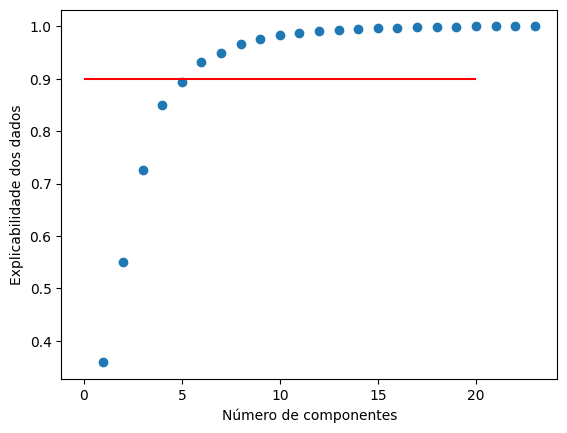

In [12]:
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(dados_tratados)
explainability = pca.explained_variance_ratio_.cumsum()
factors = np.arange(1,dados_tratados.shape[1]+1,1)
plt.scatter(factors,explainability)
plt.hlines(0.9,0,20,'r')
plt.xlabel('Número de componentes')
plt.ylabel('Explicabilidade dos dados')

p = factors[explainability<0.9].max()+1

if p<2:
    p=2

print('90% dos dados são explicados com  ' + str(p) + ' componentes.')

pca = PCA(n_components=p)
pca.fit(dados_tratados)
X = pca.transform(dados_tratados)

## **4) Olhando as três primeiras componentes principais do PCA, quais variáveis da tabela são mais importantes para o agrupamento dos dados?**
### **Resposta :**

A seguir são apresentados os valores absolutos dos elementos das três componentes principais do PCA.

In [13]:
abs(pca.components_[:3])

array([[6.04690283e-01, 5.31516856e-01, 1.82044926e-01, 3.31215647e-01,
        8.64427299e-03, 2.10915640e-01, 5.19143411e-04, 7.81603203e-03,
        9.31731258e-04, 1.59247438e-03, 5.33063294e-02, 2.47742084e-01,
        5.38160149e-03, 1.01678624e-03, 1.03497082e-03, 1.34436288e-03,
        1.81059352e-01, 7.96089178e-02, 4.43402697e-03, 1.39940513e-02,
        4.94333632e-04, 5.11134835e-03, 2.46491231e-01],
       [4.23630914e-02, 9.62928554e-02, 8.82314516e-01, 4.35296458e-01,
        1.18375938e-02, 8.16604553e-02, 6.74232332e-03, 1.18307319e-02,
        1.52405545e-03, 6.07930687e-03, 5.51573663e-02, 3.51213792e-02,
        1.01811509e-02, 1.91034979e-03, 1.91171243e-03, 3.67294210e-03,
        4.87122695e-02, 3.75891016e-02, 5.75655962e-02, 2.99215425e-02,
        4.21382080e-03, 2.25927137e-02, 3.18507829e-02],
       [4.80006965e-01, 3.31155972e-01, 2.43153108e-01, 6.66809402e-01,
        6.55306103e-03, 8.50122466e-02, 6.07966915e-03, 1.75548515e-02,
        3.95770826e-04

Observando os valores (absolutos) dos elementos, vemos que para a primeira componente do PCA, os maiores valores são os das duas primeiras colunas, correspondentes as variáveis "Temperatura" e "L". Para a segunda componente do PCA, as variáveis com maior "peso" são as variáveis das colunas 3 e 4, sendo elas as variáveis "R" e "A_M". Já para a terceira componente do PCA, os maiores valores obtidos foram os das colunas 1 e 4, correspondentes as variáveis "Temperatura" e "A_M".

## **5) Utilize o método de agrupamento hierárquico para agrupar as estrelas de acordo com suas características. Qual o número de agrupamentos ideal para análise desses dados?**
### **Resposta :**

O agrupamento hierárquico que será utilizado é o agrupamento aglomerativo. Para estimar o número ideal de agrupamentos, será realizada uma análise de silhueta considerando o fator de silhueta, o número de pontos mal atribuídos e a razão entre eles, denominada métrica de performance, em função do número de clusters (agrupamentos).

In [14]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_samples, silhouette_score

In [15]:
Ns = np.asarray([2, 3, 4, 5, 6, 7, 8, 9])
silhueta_scores = np.zeros(len(Ns))
pontos_bad = np.zeros(len(Ns))

for i,N in enumerate(Ns):
    aggclust = AgglomerativeClustering(n_clusters=N, linkage='ward').fit(X)
    categorias = aggclust.labels_
    silhueta_scores[i] = silhouette_score(X, categorias)
    sample_silhouette_values = silhouette_samples(X, categorias)
    mask = ( sample_silhouette_values < 0 )
    pontos_bad[i] = (100 * mask.sum() / len(mask)).round(2)

Text(0.5, 1.0, 'Fator de silhueta em função do número de clusters')

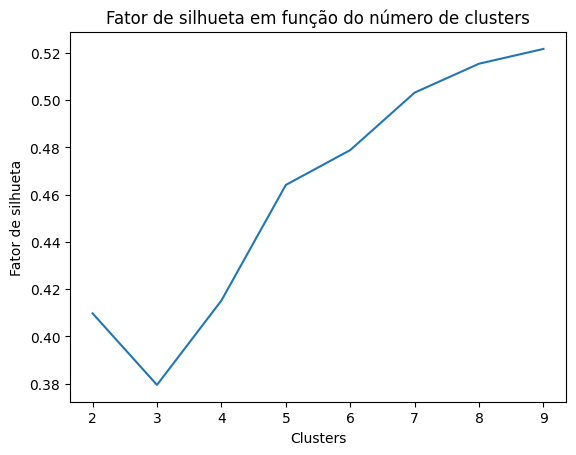

In [16]:
plt.plot(Ns,silhueta_scores)
plt.xlabel('Clusters')
plt.ylabel('Fator de silhueta')
plt.title('Fator de silhueta em função do número de clusters')

Text(0.5, 1.0, 'Pontos mal atribuídos em função do número de clusters')

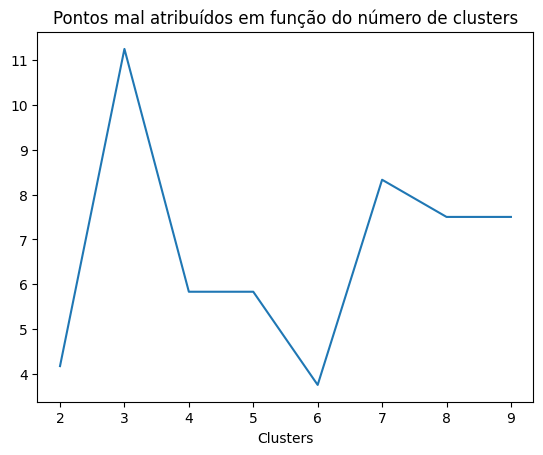

In [17]:
plt.figure()
plt.plot(Ns,pontos_bad)
plt.xlabel('Clusters')
plt.title('Pontos mal atribuídos em função do número de clusters')

Text(0.5, 1.0, 'Métrica de performance em função do número de clusters')

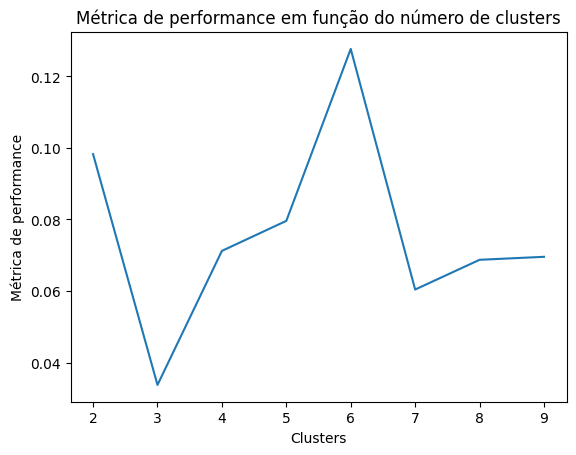

In [18]:
plt.figure()
plt.plot(Ns,silhueta_scores/pontos_bad)
plt.xlabel('Clusters')
plt.ylabel('Métrica de performance')
plt.title('Métrica de performance em função do número de clusters')

In [ ]:
opt_n_clusters = Ns[(silhueta_scores/pontos_bad).argmax()]
opt_n_clusters

np.int64(6)

O número de clusters ideal obtido, utililizando como critério a métrica de performance, foi $6$. A seguir é apresentada a classificação feita pelo método agrupamento hierárquico aglomerativo a cada um dos elementos amostrais utilizando com critério $6$ clusters.

In [20]:
aggclust = AgglomerativeClustering(n_clusters=6, linkage='ward').fit(X)
categorias = aggclust.labels_
categorias

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 2, 5, 5, 5, 5, 5, 5, 5, 5, 5, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 4, 4, 5, 5, 5, 5, 5, 5, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 2, 2, 3, 5,
       5, 5, 5, 5, 5, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2, 2, 0, 0,
       2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 4, 0, 0,
       0, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 3, 3, 5, 2, 3, 5, 5, 3, 5,
       2, 2, 2, 1, 2, 2, 1, 1, 1, 1, 2, 2, 1, 1, 1, 2, 1, 2, 2, 2])

## **6) Utilize o método KMeans para agrupar as estrelas de acordo com suas características. Qual o número de agrupamentos ideal para análise desses dados?**
### **Resposta :**

Assim como no caso do agrupamento hierárquico, o número ideal de agrupamentos será estimado a partir de uma análise de silhueta considerando o fator de silhueta, o número de pontos mal atribuídos e a métrica de performance, em função do número de agrupamentos.

In [21]:
from sklearn.cluster import KMeans

In [29]:
Ns = np.asarray([2, 3, 4, 5, 6, 7, 8, 9])
silhueta_scores = np.zeros(len(Ns))
pontos_bad = np.zeros(len(Ns))

for i,N in enumerate(Ns):
    kmeans = KMeans(n_clusters=N).fit(X)
    categorias = kmeans.labels_
    silhueta_scores[i] = silhouette_score(X, categorias)
    sample_silhouette_values = silhouette_samples(X, categorias)
    mask = ( sample_silhouette_values < 0 )
    pontos_bad[i] = (100 * mask.sum() / len(mask)).round(2)

Text(0, 0.5, 'Fator de silhueta')

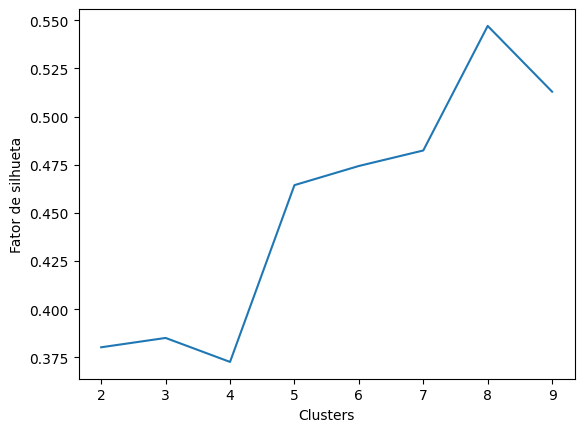

In [30]:
plt.plot(Ns,silhueta_scores);
plt.xlabel('Clusters')
plt.ylabel('Fator de silhueta')

Text(0, 0.5, 'Pontos mal atribuídos')

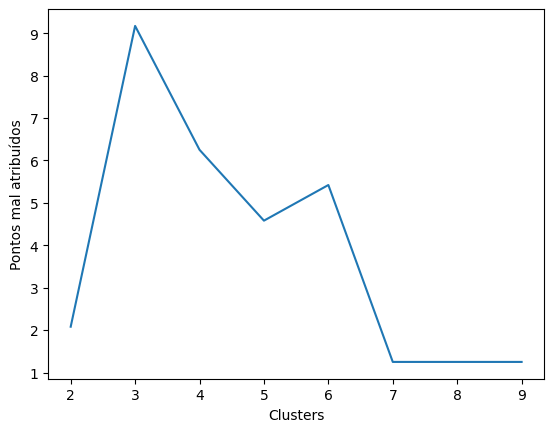

In [31]:
plt.figure()
plt.plot(Ns,pontos_bad)
plt.xlabel('Clusters')
plt.ylabel('Pontos mal atribuídos')

Text(0, 0.5, 'Métrica de performance')

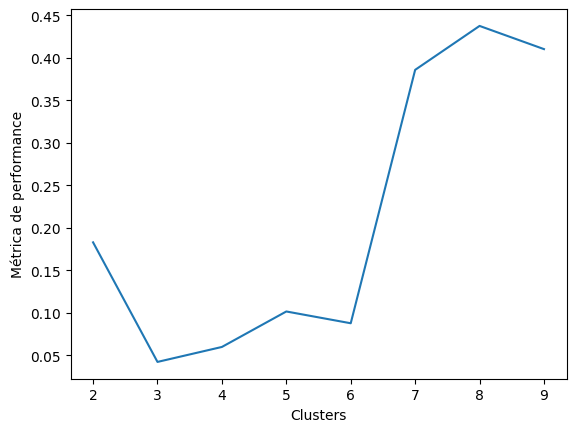

In [32]:
plt.figure()
plt.plot(Ns,silhueta_scores/pontos_bad)
plt.xlabel('Clusters')
plt.ylabel('Métrica de performance')

In [33]:
opt_n_clusters = Ns[(silhueta_scores/pontos_bad).argmax()]
opt_n_clusters

np.int64(8)

Utililizando como critério a métrica de performance, o número ideal de agrupamentos obtido foi $8$. A seguir é apresentada a classificação feita pelo método KMeans a cada um dos elementos amostrais utilizando com critério $8$ clusters.

In [34]:
kmeans = KMeans(n_clusters=8).fit(X)
categorias = kmeans.labels_
categorias

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 1, 1, 1, 1, 1, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 6, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 7, 1, 1,
       7, 7, 1, 1, 1, 6, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 4, 4, 2, 2, 2, 2, 2, 2, 6, 6, 0, 6, 6, 2, 6, 6, 6, 6, 6,
       7, 7, 7, 7, 7, 7, 7, 1, 7, 7, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 6, 7, 3, 2,
       2, 2, 2, 2, 2, 6, 6, 5, 6, 6, 6, 2, 6, 6, 6, 6, 7, 7, 7, 6, 7, 7,
       6, 7, 2, 6, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 1, 4, 1, 1,
       1, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 2, 6, 3, 2, 2, 3, 2,
       6, 6, 6, 5, 6, 6, 5, 5, 5, 5, 6, 6, 0, 0, 0, 6, 0, 7, 7, 6],
      dtype=int32)

**Observação :** O método KMeans utiliza sementes aleatórias, o que faz com que a cada chamada do método seja obtido um resultado diferente. Além disso, para utilizar a métrica de performance, é necessário que o número de pontos mal atribuídos não seja zero. Caso isso ocorra, o número ideal de agrupamentos pode ser tomado como o que maximiza o fator de silhueta apenas.

## **7) Utilize o método DBSCAN para agrupar as estrelas de acordo com suas caraterísticas. Qual o número de agrupamentos obtido? Comente sobre a presença ou não de outliers.**
### **Resposta :**

Utilizando $eps = 0.5$ e o número mínimo de amostras igual a $10$, foi obtido pelo método DBSCAN a seguinte classificação dos elementos amostrais.

In [58]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=10).fit(X)
categorias = dbscan.labels_
categorias

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,
        0,  0,  0,  2,  1,  1,  1,  2,  1, -1,  1,  1,  1, -1, -1,  2, -1,
        1,  1,  1,  1, -1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  3,
        3,  3, -1,  3,  3, -1,  3,  3,  3,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  1,  2,  2,
       -1,  2,  2,  1,  4,  1, -1, -1,  1, -1, -1, -1,  1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1,  3,  3,  3,  3,  3,  3, -1,  3, -1,
        3,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  2,  4,  4,  2,  2, -1,  2,  1,  1,  2, -1, -1, -1,
        2,  2, -1, -1,  2, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
        3,  3, -1, -1,  3,  3, -1, -1, -1, -1,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0, -1,  0, -1,  0,  0,  0, -1,  4,  4,  4,  4,
        4,  4,  4,  4,  4,  4,  2, -1, -1,  2, -1, -1, -1,  2, -1,  1, -1,
       -1, -1, -1, -1, -1

In [60]:
N_clusters = max(categorias) + 1
N_outliers = sum(categorias == -1)
N_clusters,N_outliers,91/240

(np.int64(5), np.int64(91), 0.37916666666666665)

Para as escolhas de "eps" e "min_samples" adotadas, foram obtidos $5$ agrupamentos e $91$ outliers. A proporção de outliers obtida foi relativamente alta, de aproximadamente $38$%.

## **8) Faça uma análise sobre a performance geral dos algoritmos utilizados nos itens de 5 a 7 comparando com as categorias definidas manualmente e que podem ser encontradas no arquivo Categorias.csv.**
### **Resposta :**

In [63]:
Categorias = pd.read_csv('Categorias.csv')
Categorias

,Star,Type
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0
...,...,...
235,236,5
236,237,5
237,238,5
238,239,5


Realizar a comparação entre as classificações obtidas pelos métodos e a classificação do arquivo Categorias.csv apresenta uma dificldade inicial que é a ordenação das categorias, que pode ser distinta da ordenação utilizada no arquivo. A ordenação entre os diferentes métodos também pode diferir. A classificação de elementos como outliers no DBSCAN também é algo que dificulta a comparação dele com os demais métodos e com dados do arquivo, já que nenhum deles tem essa classificação. O que se pode notar no arquivo Categorias.csv, no entanto, é que conjuntos de dez elementos amostrais consecutivos pertencem a mesma categoria. Este padrão de elementos amostrais consecutivos pertencerem a uma mesma categoria (não exatamente dez elementos) é observado em todos os métodos, principalmente os que não classificam elementos como outliers (agrupamento hierárquico e KMeans). Em relação ao número de agrupamentos, o método que estimou melhor este número foi o de agrupamento hierárquico, visto que o número de agrupamentos apresentado no arquivo é $6$.        